# Task 2: Quantitative Analysis - Technical & Financial Metrics

This notebook performs quantitative analysis on stock data for multiple companies, including technical indicators using `TA-Lib` and financial performance metrics.

In [1]:
import pandas as pd
import numpy as np
import talib
import yfinance as yf
import matplotlib.pyplot as plt
import mplfinance as mpf
import os
from datetime import datetime

# Setup
os.makedirs('figures', exist_ok=True)
plt.style.use('ggplot')
print("Setup complete.")

Setup complete.


## 1. Load and Clean Data

In [2]:
tickers = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']
stock_data = {}

for ticker in tickers:
    path = f'../data/raw/{ticker}.csv'
    if not os.path.exists(path):
        path = f'data/raw/{ticker}.csv'
    
    if os.path.exists(path):
        df = pd.read_csv(path, index_col=0, parse_dates=True)
        stock_data[ticker] = df
        print(f"Loaded {ticker}: {len(df)} rows.")
    else:
        print(f"Warning: Could not find data for {ticker}")

Loaded AAPL: 3774 rows.
Loaded AMZN: 3774 rows.
Loaded GOOG: 3774 rows.
Loaded META: 2923 rows.
Loaded NVDA: 3774 rows.


## 2. Technical Indicators (TA-Lib)

For each stock, we compute:
- **SMA**: 10, 20, 50 days
- **EMA**: 10, 20, 50 days
- **RSI**: 14-period
- **MACD**: 12/26/9 config
- **Daily Returns**

In [3]:
for ticker, df in stock_data.items():
    close = df['Close'].values
    
    # SMAs
    df['SMA_10'] = talib.SMA(close, timeperiod=10)
    df['SMA_20'] = talib.SMA(close, timeperiod=20)
    df['SMA_50'] = talib.SMA(close, timeperiod=50)
    
    # EMAs
    df['EMA_10'] = talib.EMA(close, timeperiod=10)
    df['EMA_20'] = talib.EMA(close, timeperiod=20)
    df['EMA_50'] = talib.EMA(close, timeperiod=50)
    
    # RSI
    df['RSI'] = talib.RSI(close, timeperiod=14)
    
    # MACD
    macd, macdsignal, macdhist = talib.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
    df['MACD'] = macd
    df['MACD_Signal'] = macdsignal
    df['MACD_Hist'] = macdhist
    
    # Daily Returns (Use Adj Close if available, else Close)
    price_col = 'Adj Close' if 'Adj Close' in df.columns else 'Close'
    df['Daily_Return'] = df[price_col].pct_change() * 100
    
    print(f"Computed indicators for {ticker}")

Computed indicators for AAPL
Computed indicators for AMZN
Computed indicators for GOOG
Computed indicators for META
Computed indicators for NVDA


## 3. Performance Metrics

We calculate Sharpe Ratio and Rolling Volatility manually, and fetch basic info using `yfinance`.

In [4]:
metrics_summary = []

for ticker, df in stock_data.items():
    # Sharpe Ratio (assuming risk-free rate = 0 for simplicity)
    returns = df['Daily_Return'].dropna()
    sharpe_ratio = (returns.mean() / returns.std()) * np.sqrt(252)
    
    # Rolling Volatility (20-day)
    df['Volatility_20'] = df['Daily_Return'].rolling(20).std() * np.sqrt(252)
    
    # Fetch basic info from yfinance
    try:
        info = yf.Ticker(ticker).info
        market_cap = info.get('marketCap', 'N/A')
        beta = info.get('beta', 'N/A')
    except:
        market_cap = 'N/A'
        beta = 'N/A'
    
    price_col = 'Adj Close' if 'Adj Close' in df.columns else 'Close'
    metrics_summary.append({
        'Ticker': ticker,
        'Total Return (%)': ((df[price_col].iloc[-1] / df[price_col].iloc[0]) - 1) * 100,
        'Sharpe Ratio': sharpe_ratio,
        'Avg Volatility (%)': df['Volatility_20'].mean(),
        'Market Cap': market_cap,
        'Beta': beta
    })

pd.DataFrame(metrics_summary)

,Ticker,Total Return (%),Sharpe Ratio,Avg Volatility (%),Market Cap,Beta
0,AAPL,6907.742611,1.136250,26.273206,4279145070592,1.065
1,AMZN,5490.140032,0.947247,31.624756,2898933317632,1.468
2,GOOG,1660.964064,0.833560,25.139883,4687828353024,1.267
3,META,825.869815,0.679362,35.209300,1520160079872,1.243
4,NVDA,24691.753885,1.030366,41.748053,5330086920192,2.244


## 4. Visualizations

Multi-panel figures including Price/SMA/EMA, RSI, and MACD.

Saved plot for AAPL to figures/AAPL_analysis.png


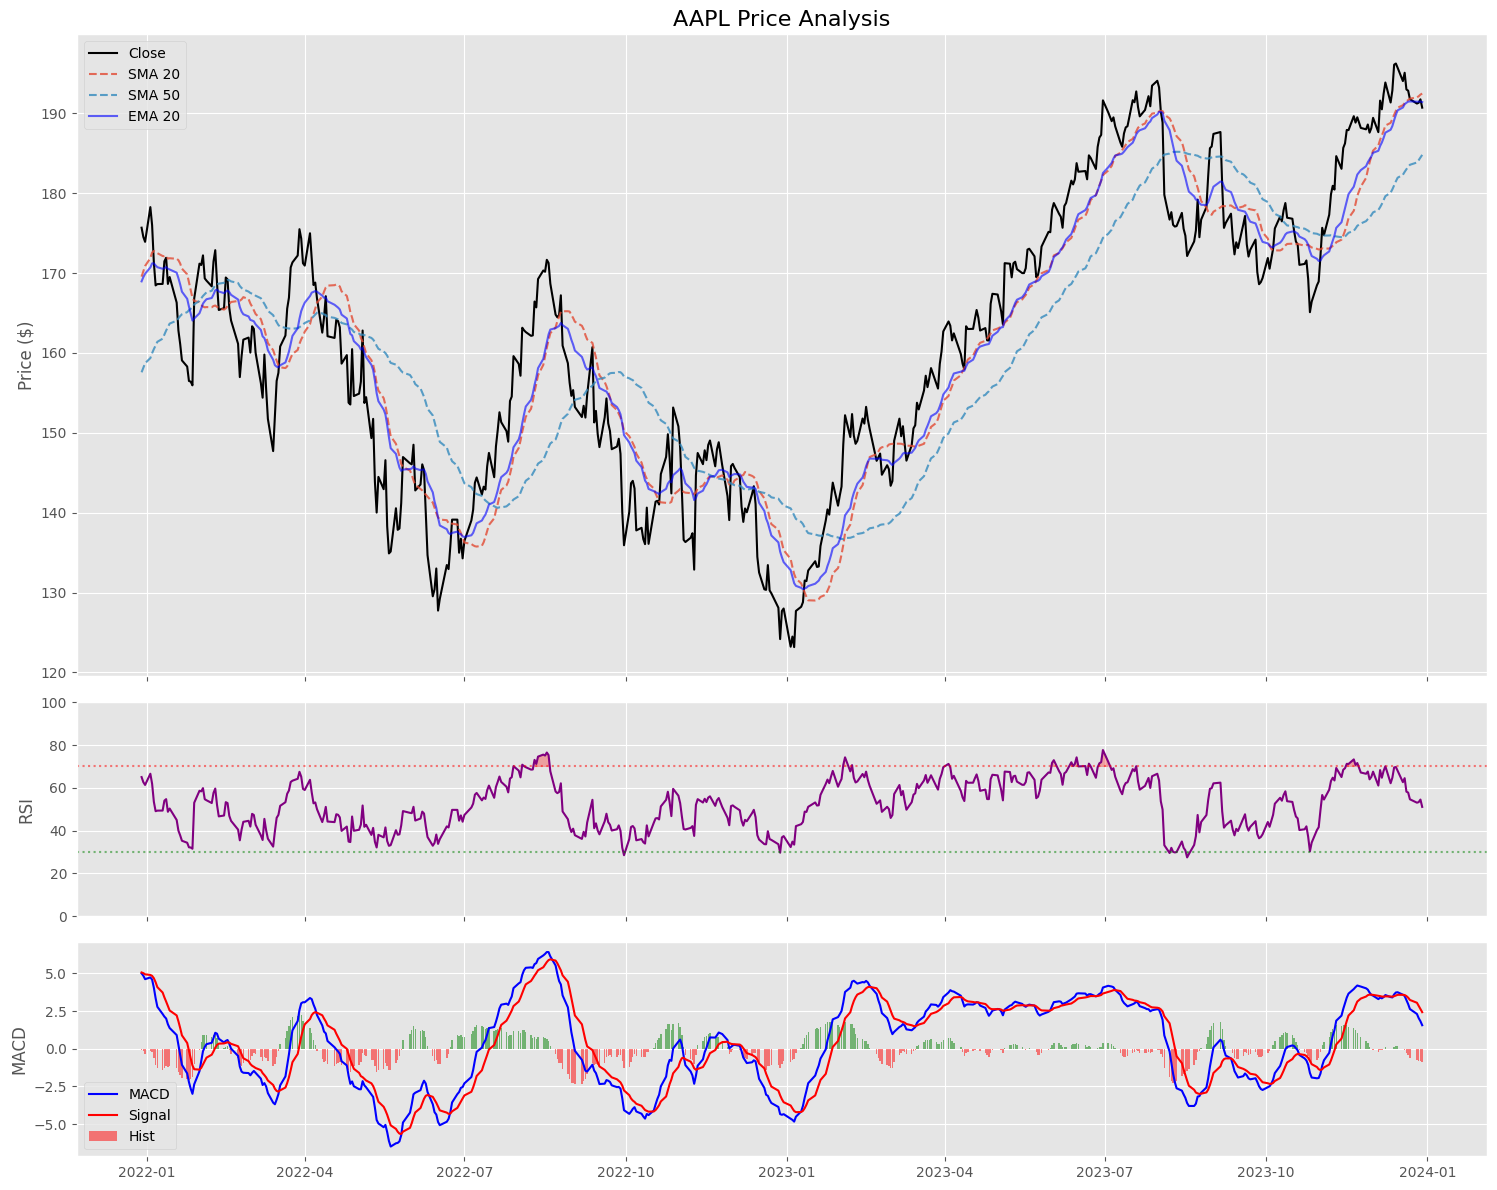

Saved plot for AMZN to figures/AMZN_analysis.png


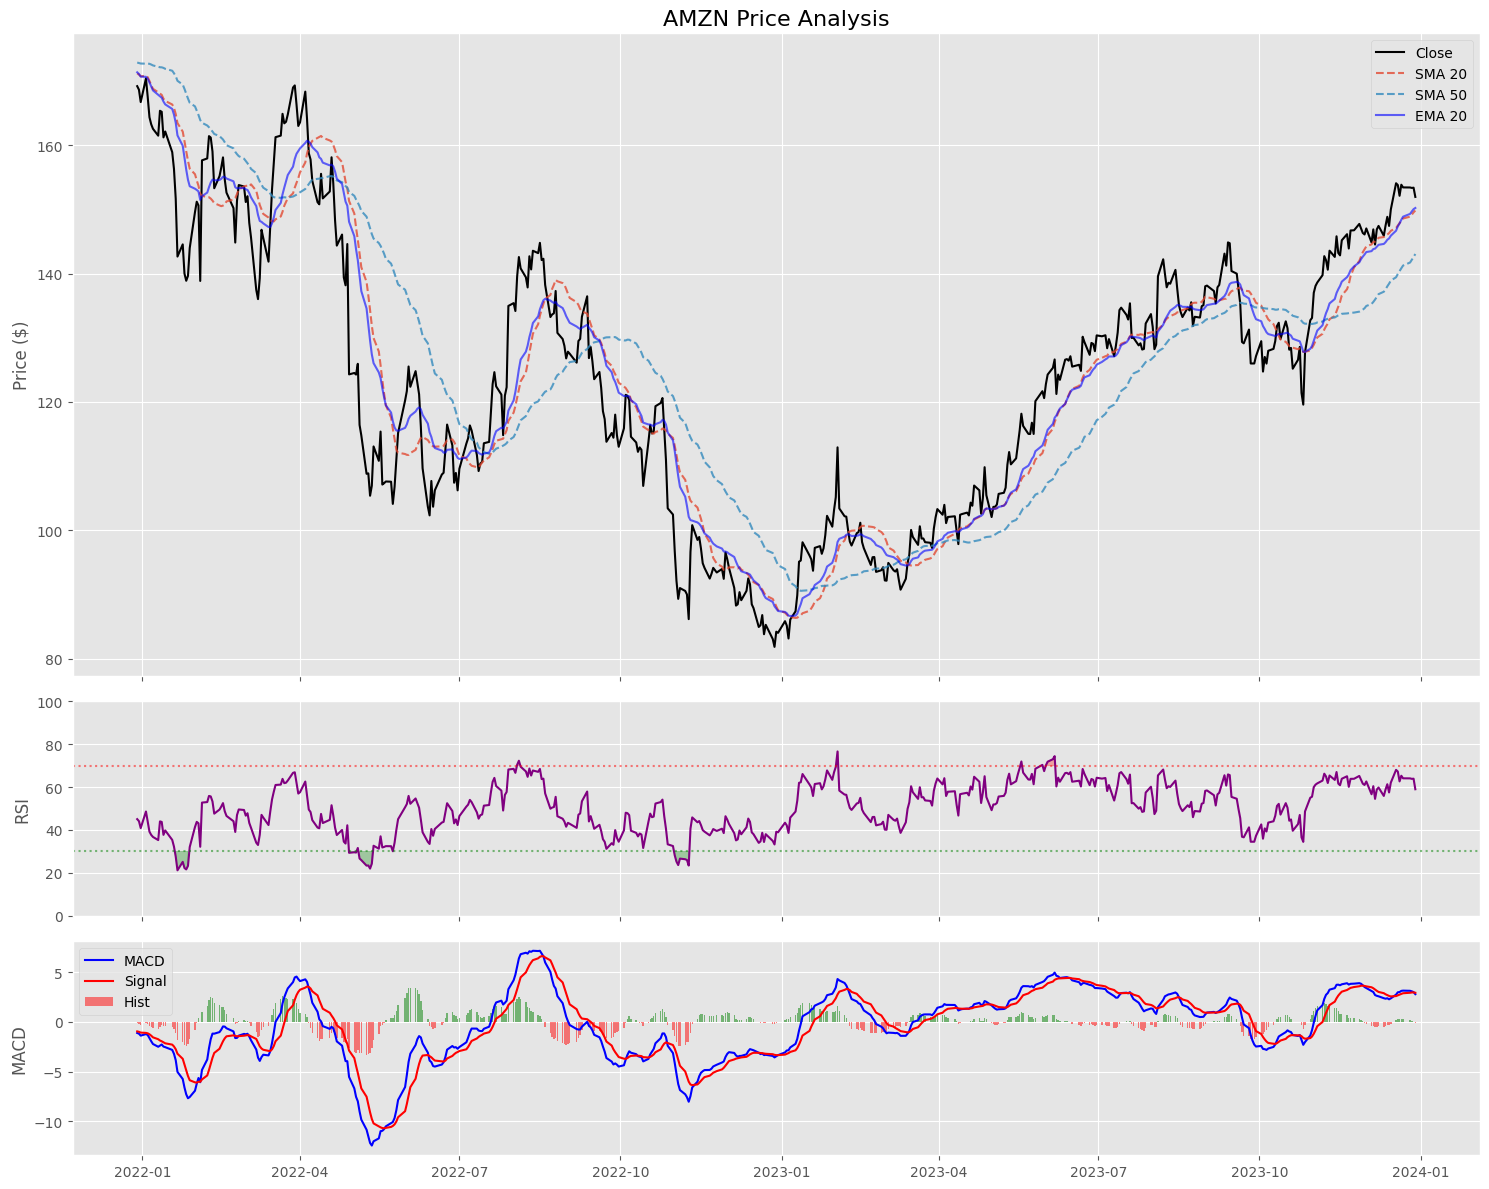

In [5]:
def plot_stock_analysis(ticker, df):
    # Filter recent data for better visibility (last 2 years)
    cutoff = df.index.max() - pd.DateOffset(years=2)
    plot_df = df.loc[df.index >= cutoff]
    
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True, gridspec_kw={'height_ratios': [3, 1, 1]})
    
    # Top Panel: Price and Averages
    price_col = 'Adj Close' if 'Adj Close' in plot_df.columns else 'Close'
    ax1.plot(plot_df.index, plot_df[price_col], label=price_col, color='black', linewidth=1.5)
    ax1.plot(plot_df.index, plot_df['SMA_20'], label='SMA 20', linestyle='--', alpha=0.8)
    ax1.plot(plot_df.index, plot_df['SMA_50'], label='SMA 50', linestyle='--', alpha=0.8)
    ax1.plot(plot_df.index, plot_df['EMA_20'], label='EMA 20', color='blue', alpha=0.6)
    ax1.set_title(f'{ticker} Price Analysis', fontsize=16)
    ax1.set_ylabel('Price ($)')
    ax1.legend()
    
    # Middle Panel: RSI
    ax2.plot(plot_df.index, plot_df['RSI'], color='purple')
    ax2.axhline(70, color='red', linestyle=':', alpha=0.5)
    ax2.axhline(30, color='green', linestyle=':', alpha=0.5)
    ax2.fill_between(plot_df.index, plot_df['RSI'], 70, where=(plot_df['RSI'] >= 70), color='red', alpha=0.3)
    ax2.fill_between(plot_df.index, plot_df['RSI'], 30, where=(plot_df['RSI'] <= 30), color='green', alpha=0.3)
    ax2.set_ylabel('RSI')
    ax2.set_ylim(0, 100)
    
    # Bottom Panel: MACD
    ax3.plot(plot_df.index, plot_df['MACD'], label='MACD', color='blue')
    ax3.plot(plot_df.index, plot_df['MACD_Signal'], label='Signal', color='red')
    
    # MACD Histogram
    colors = ['green' if x >= 0 else 'red' for x in plot_df['MACD_Hist']]
    ax3.bar(plot_df.index, plot_df['MACD_Hist'], color=colors, alpha=0.5, label='Hist')
    ax3.set_ylabel('MACD')
    ax3.legend()
    
    plt.tight_layout()
    
    # Save figure
    os.makedirs('figures', exist_ok=True)
    save_path = f'figures/{ticker}_analysis.png'
    plt.savefig(save_path)
    print(f"Saved plot for {ticker} to {save_path}")
    plt.show()

# Plot for a couple of stocks
for ticker in tickers[:2]:
    plot_stock_analysis(ticker, stock_data[ticker])